# Pruebas STAR

## Código base

In [1]:
source("utils.r")
source("preparar_dataframes.r")
library(tsDyn)
library(sstvars)

[1] "Se creó df_trimestral_crudo"
[1] "Se creó df_Arg"
[1] "Se creó df_ERPT_Arg1"
[1] "Se creó df_ERPT_Arg"


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘sstvars’


The following object is masked from ‘package:tsDyn’:

    GIRF




## Experimentos

In [2]:
df_ERPT_Arg

,año,trimestre,ipc,E,Ebc,pbird,impp_usa,Psoja_USA,Pmaíz_USA,Ptrigo_USA,TOTfmi
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,1950,2ºTr,0.0710476068,0.000000e+00,0.000000e+00,-0.016444578,NA,0.209470249,0.123481057,0.058301271,NA
3,1950,3ºTr,0.0485426448,1.822569e-01,1.822569e-01,0.037674929,NA,-0.048727588,0.087011377,-0.046365921,NA
4,1950,4ºTr,0.0686389229,2.596392e-01,2.596392e-01,-0.012975314,NA,-0.045706880,-0.030554668,-0.006802747,NA
5,1951,1ºTr,0.0228032118,1.405321e-03,1.405321e-03,0.027127918,NA,0.222317901,0.123336402,0.091268514,NA
6,1951,2ºTr,0.1578569708,4.855918e-03,4.855918e-03,0.012084985,NA,0.016384856,0.029108084,-0.014117882,NA
7,1951,3ºTr,0.1057701537,6.299697e-03,6.299697e-03,-0.006213927,NA,-0.123214880,0.010193768,-0.025601398,NA
8,1951,4ºTr,0.0767790005,1.347034e-02,1.347034e-02,-0.004386448,NA,0.007326040,0.000000000,0.053640618,NA
9,1952,1ºTr,0.1087066196,-1.618821e-02,-1.618821e-02,0.002419679,NA,0.012092046,0.010090903,0.010695289,NA
10,1952,2ºTr,0.0994670088,-1.171674e-02,-1.171674e-02,-0.032405660,NA,0.022579688,0.025769513,-0.032435276,NA


# Librerías

In [3]:
library(tsDyn)
library(vars)
library(dplyr)
library(ggplot2)


Loading required package: MASS

Loading required package: strucchange

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: urca

Loading required package: lmtest


Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Configuración general

In [6]:
############################################################
# CONFIGURACIÓN 2 lags (según Selected Orders de VAR)
############################################################

lag_var        <- 2        # número de rezagos
use_scaled_ipc <- FALSE    # NO CAMBIAR. TRUE = usar ipc estandarizada
use_maíz_endog <- TRUE     # FALSE = tratar maíz como exógena (por ahora solo quita del sistema)

nboot_test     <- 200
trim_value     <- 0.15
n_regimes <- 2
thDelay_value  <- 1
include_type   <- "const"
weight_func <- "threshold"


# Preparar dataset

In [5]:
############################################################
# 1. Preparar variables
############################################################

df <- df_ERPT_Arg

# Variable de transición
ipc_trans <- df$ipc
if(use_scaled_ipc){
  ipc_trans <- scale(ipc_trans)
}

# Endógenas
if(use_maíz_endog){
  Y <- cbind(df$Pmaíz_USA, df$E, df$ipc, df$pbird)
  colnames(Y) <- c("Pmaíz_USA","E","ipc","pbird")
} else {
  Y <- cbind(df$E, df$ipc, df$pbird)
  colnames(Y) <- c("E","ipc","pbird")
}


# Test de linealidad (TVAR.LRtest) 
Esto devuelve: estadístico LR; p-value bootstrap; valores críticos. Si p-value < 0.05 hay evidencia de no linealidad. 

In [9]:
############################################################
# 2. Test de linealidad
############################################################

test_lin <- TVAR.LRtest(
  data   = Y,
  lag    = lag_var,
  series = "ipc",
  thDelay= thDelay_value,
  thVar  = ipc_trans,
  trim   = trim_value,
  nboot  = nboot_test,
  test   = "1vs",
  model  = "TAR"
)

print(test_lin)

Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning me

Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”


# Estimación TVAR

In [8]:
############################################################
# 3. Estimar TVAR
############################################################

tvar_model <- fitSTVAR(
  data     = Y,
  p      = lag_var,
  M      = n_regimes,
  weight_function = weight_func, #threshold
  weightfun_pars = c(3,1),
  nrounds = 10,
  seeds = 1:10,
  estim_method = "two-phase"
)

summary(tvar_model)


Using 2 cores for 10 estimations rounds...

PHASE 1: Estimating all the parameters with a genetic algorithm...



Results from the genetic algorithm:

The lowest loglik:  1379.289

The largest loglik: 1493.743

PHASE 2: Estimating all the parameters with a variable metric algorithm...

Results from the variable metric algorithm:

The lowest loglik:  1379.289

The largest loglik: 1493.743

Filtering inappropriate estimates...

No 'appropriate'estimates found! Check that all the variables are scaled to vary in similar magninutes, also not very small or large magnitudes.

Consider running more estimation rounds or study the obtained estimates one-by-one with the function alt_stvar.

Calculating approximate standard errors...

Warning message in warn_eigens(ret, allow_unstab = allow_unstab):
“Regimes 1 and 2 have near-singular error term covariance matrices! Consider building a model from the next-largest local maximum with the function 'alt_stvar' by adjusting its argument 'which_largest' (or use the function 'filter_estimates').”
Finished!




threshold Gaussian STVAR model, reduced form model, no AR_constraints, no mean_constraints, 
  p = 2, M = 2, d = 4, #parameters = 93, #observations = 293 x 4
  Switching variable: ipc with lag 1.

loglik/T: 5.10, AIC: -9.56, HQIC: -9.09, BIC: -8.39 

Regime 1 
Moduli of 'bold A' eigenvalues:  0.87, 0.61, 0.38, 0.30, 0.30, 0.21, 0.21, 0.01 
Cov. matrix 'Omega' eigenvalues: 0.02, 0.01, 0.00, 0.00 
Upper threshold: 0.22 
Regime means: 0.01, 0.05, 0.08, 0.01
Regime sdevs: 0.11, 0.15, 0.08, 0.03

   Y      phi0          A1                                 A2                  
1 y1 = [ -0.01 ] + [  0.19  0.13  0.19  0.23 ] y1.1 + [  0.04 -0.04 -0.02 -0.02
2 y2   [  0.04 ]   [ -0.02  0.15 -0.02 -0.08 ] y2.1   [  0.20  0.24 -0.05 -0.10
3 y3   [  0.01 ]   [  0.05  0.05  0.73 -0.08 ] y3.1   [ -0.06 -0.02  0.15 -0.09
4 y4   [  0.01 ]   [ -0.02 -0.06  0.07  0.11 ] y4.1   [  0.04  0.00  0.01 -0.05
             Omega                  1/2     
1 ] y1.2 + [  0.01 0.00 0.00 0.00 ]     eps1
2 ] y2.2   [ 

In [9]:
saveRDS(tvar_model,"sstvars_threshold_10_corridas.rds")

In [ ]:
library(sstvars)
tvar_model <- readRDS("sstvars_threshold_10_corridas.rds")

In [10]:
fit_struct <- fitSSTVAR(
  stvar = tvar_model,
  identification = "heteroskedasticity"
)

Calculating approximate standard errors...



## Plots diagnóstico

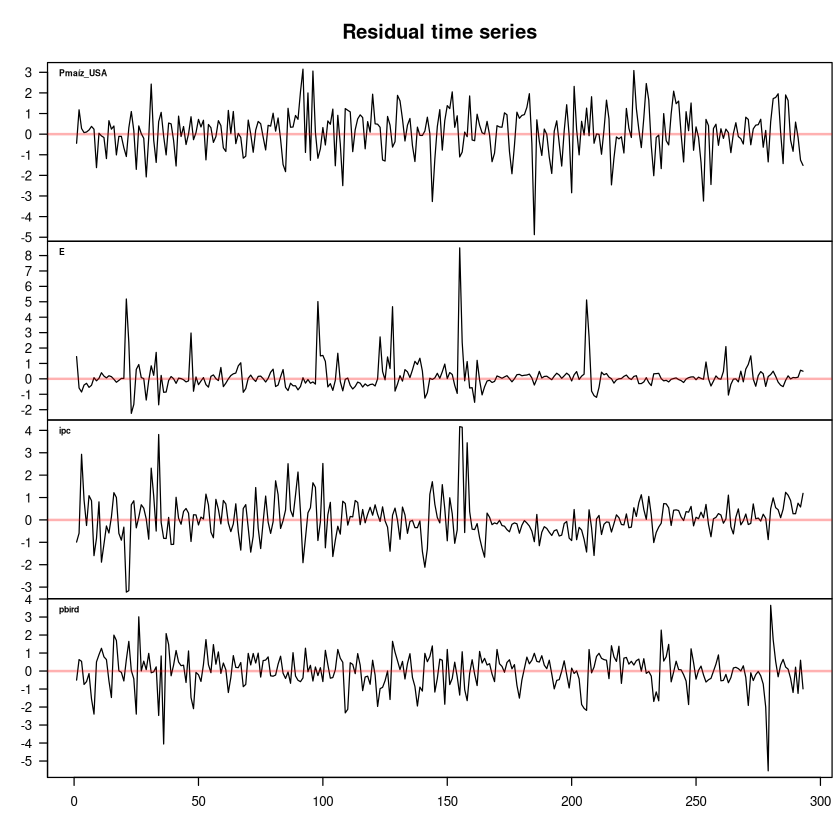

In [5]:
diagnostic_plot(tvar_model,type = "series", resid_type = "standardized", maxlag=8)

## Plots IRF

### Regimen 2

Regimen 2 - ERPT de TC a Inflación (todo en dif log)


Using 2 cores to estimate 250 GIRFs for 1 structural shocks, each based on 250 Monte Carlo repetitions.



Estimating GIRFs for structural shock 2...

Finished!



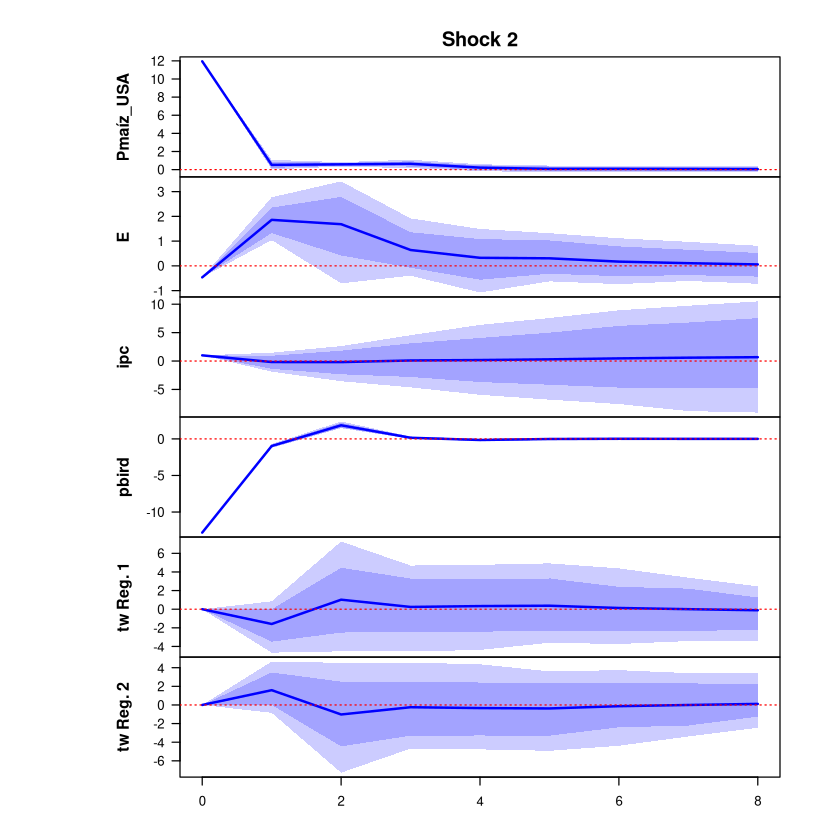

In [11]:
cat("Regimen 2 - ERPT de TC a Inflación (todo en dif log)\n")

girf_erpt <- GIRF(
  fit_struct,
  N = 8,                          # horizonte
  which_shocks = 2,               # shock al Tipo de Cambio (variable 2)
  which_cumulative = 3,           # acumula la respuesta de inflación (variable 3)
  init_regime = 2,
  scale = c(2, 3, 1),          # ← clave: shock a TC que genera +1% (0.01) en inflación instantánea
  scale_type = "instant"          # Recomendado para ERPT
)

plot(girf_erpt, 
     main = "ERPT: Efecto acumulado de inflación ante shock de TC\n(Regimen 2 - Todo en dif log)")

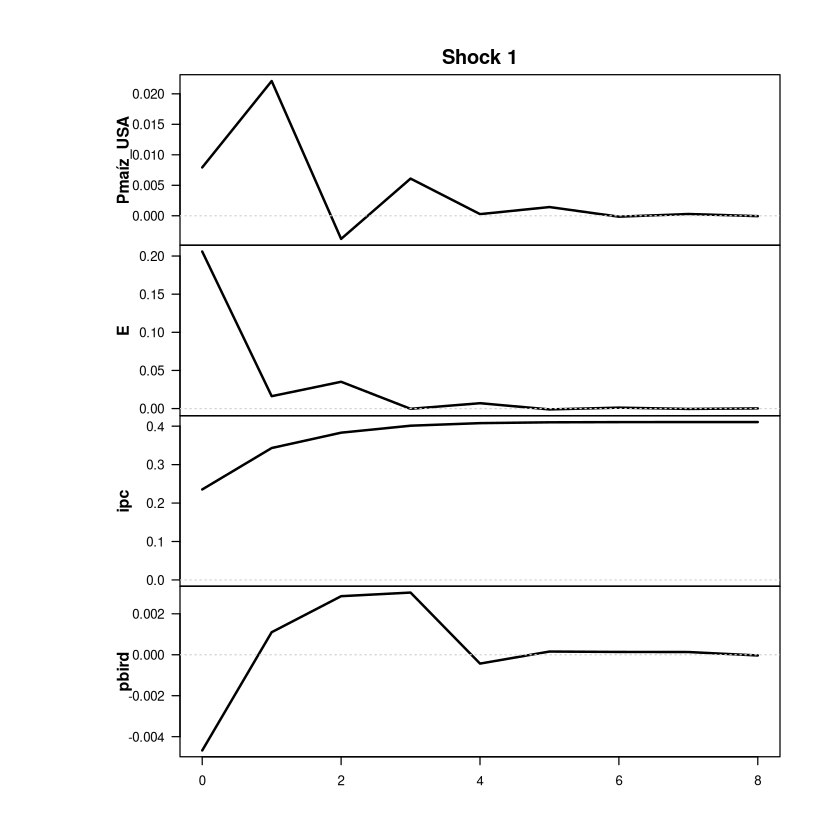

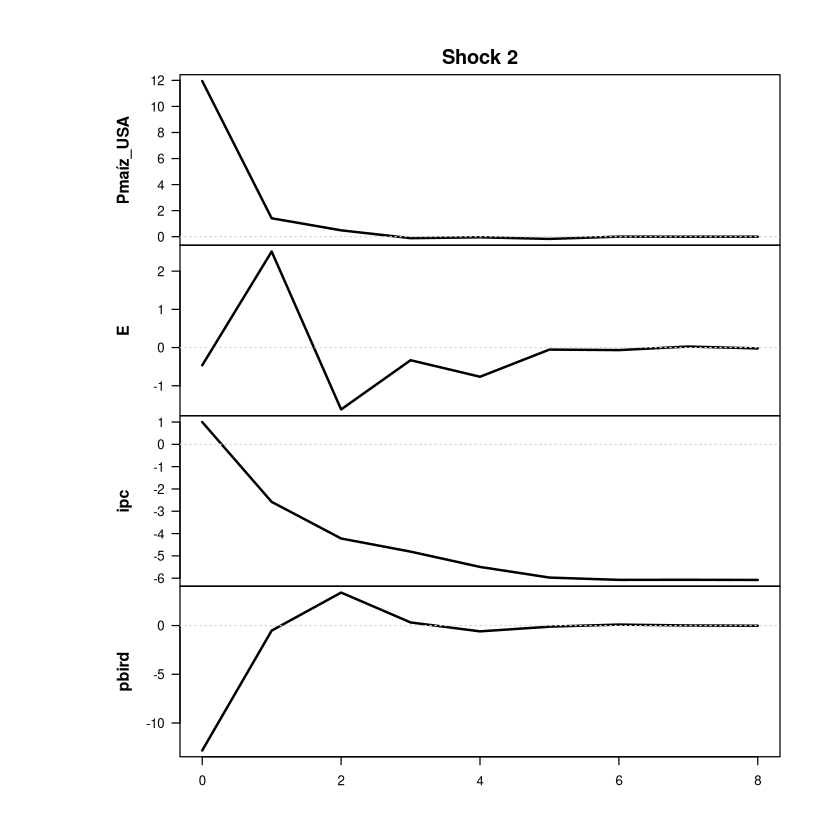

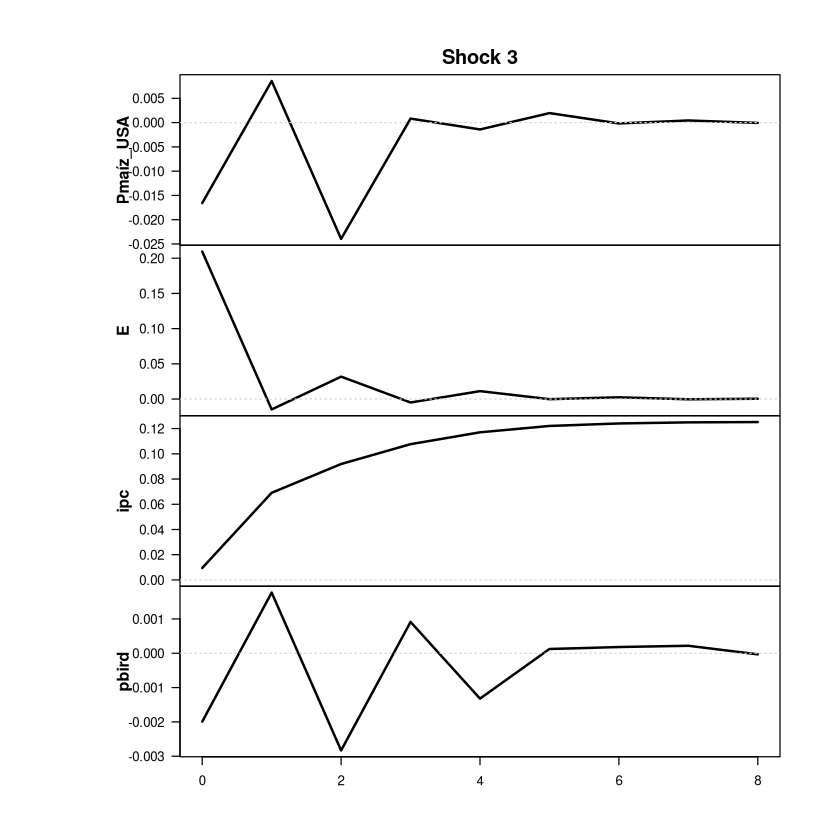

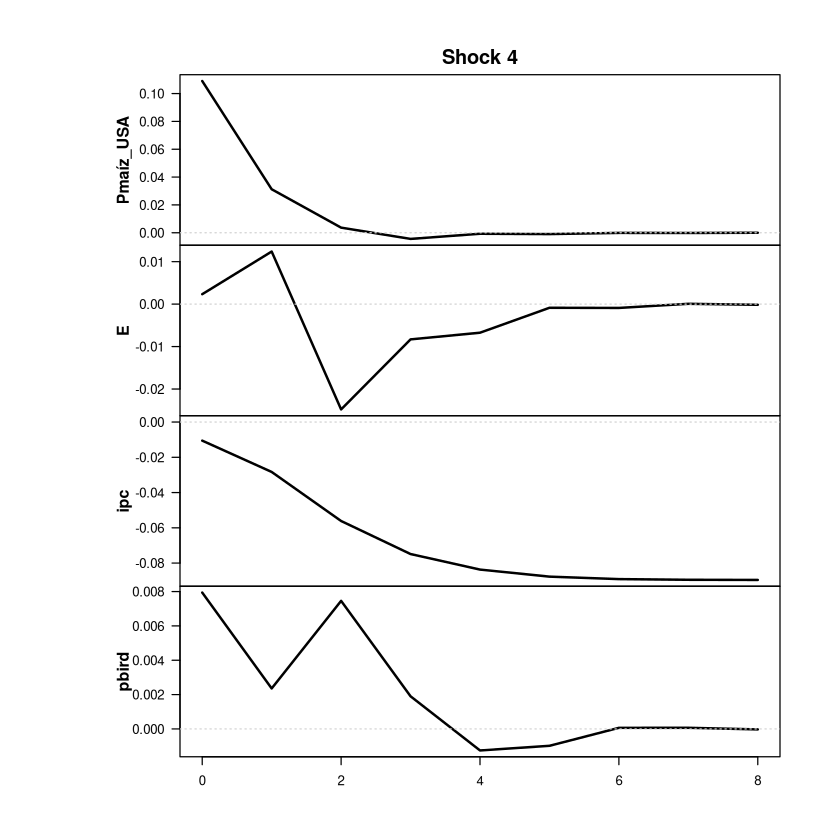

In [12]:
irf_struct <- linear_IRF(
  fit_struct,
  N = 8,                    # horizonte de 8 periodos
  regime = 2,
  which_cumulative = 3,     # acumula las respuestas de la inflación (variable 3)
  scale = c(2, 3, 1),       # ← CLAVE: shock en TC (2) → +1 en inflación (3)
  # scale = matrix(c(2, 3, 1), ncol = 1)   # forma equivalente
  ncores = 2
)

plot(irf_struct)

Regimen 2

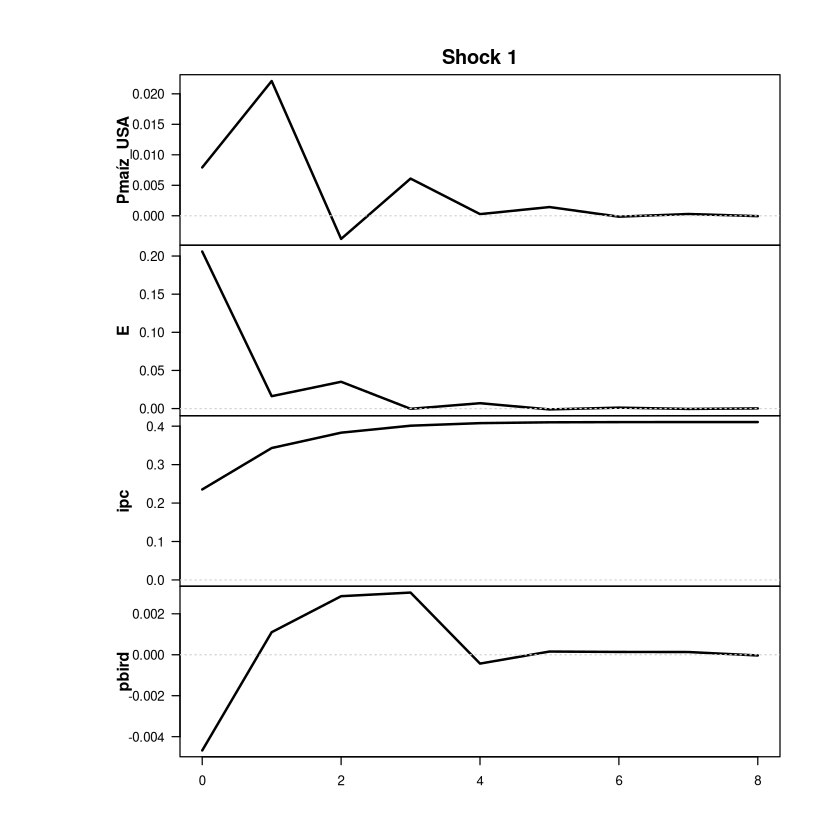

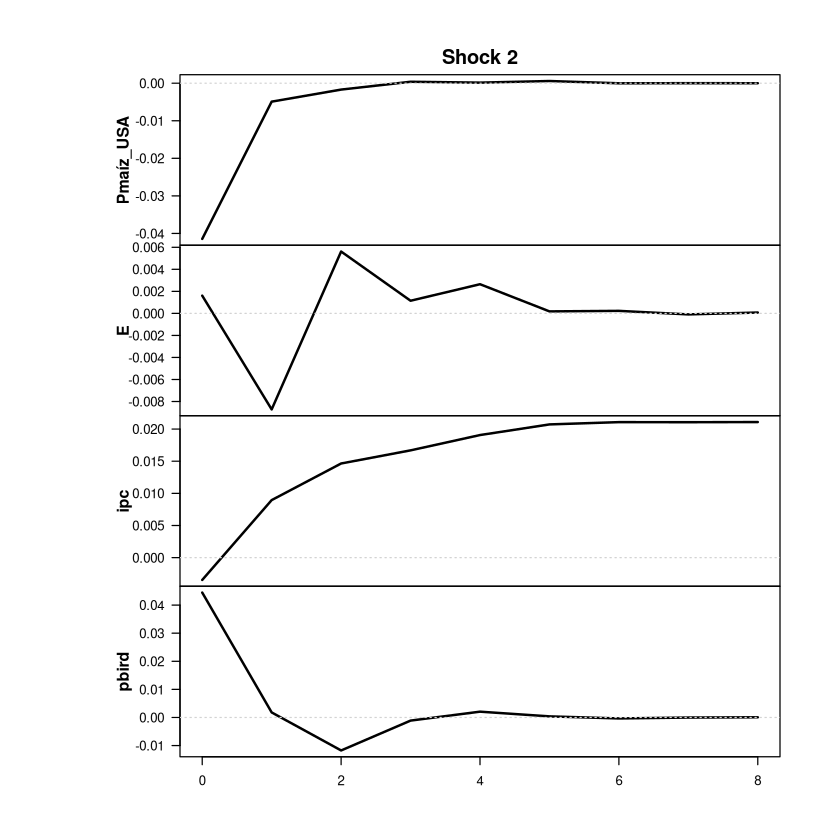

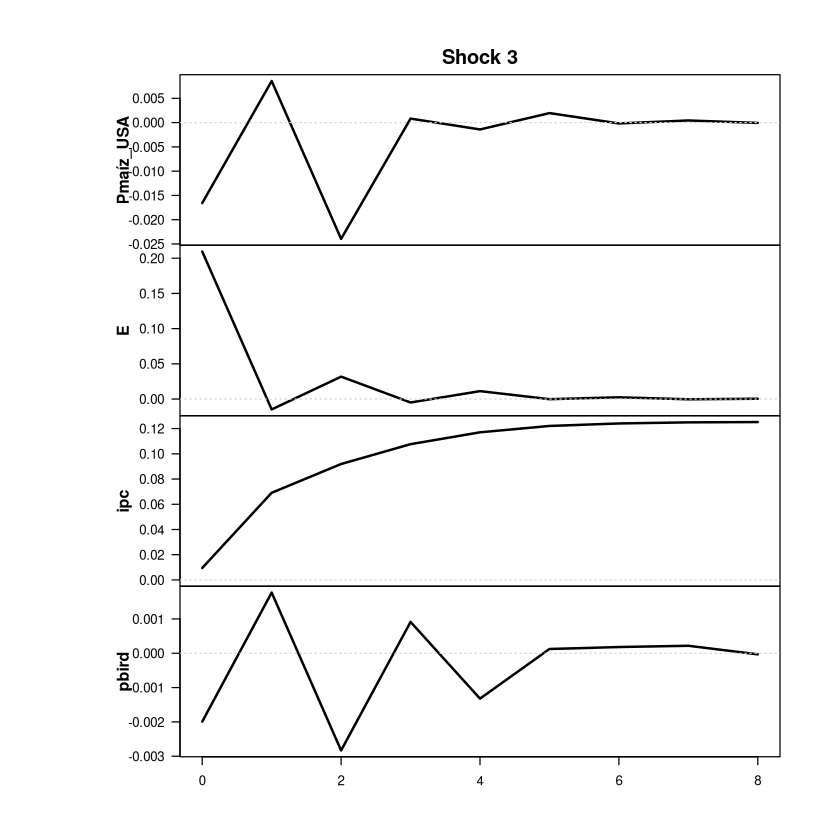

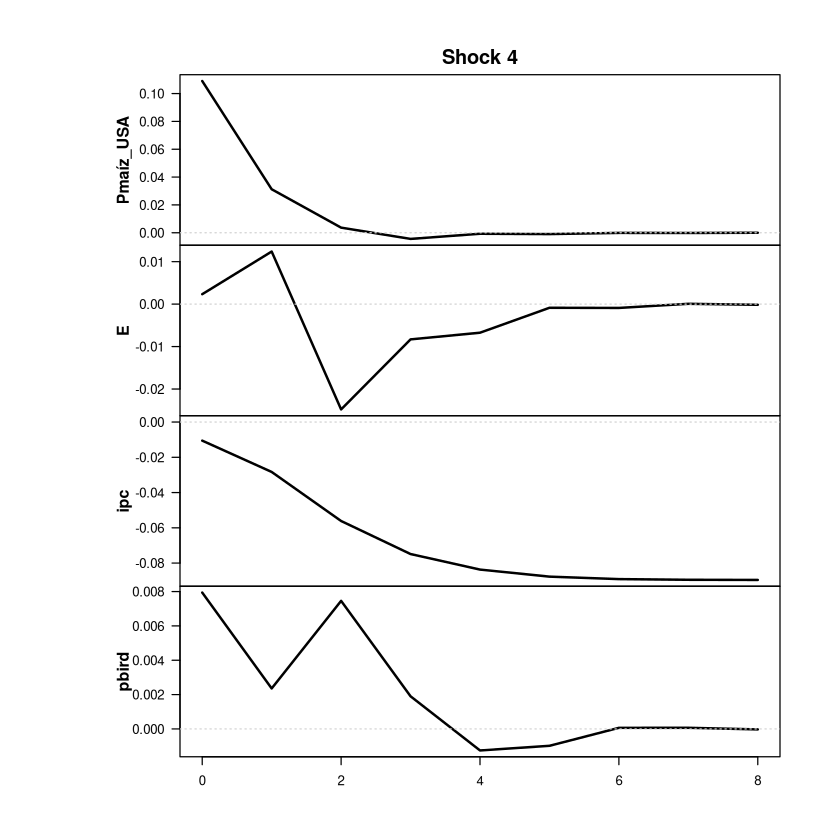

In [13]:
cat("Regimen 2")
irf_struct <- linear_IRF(
  fit_struct,
  N = 8,
  regime = 2,
  which_cumulative = 3,
  #ci = 0.68,
  scale = NULL,
  ncores = 2,
  #robust_method = c("Nelder-Mead", "SANN", "none"),
)
plot(irf_struct)


### Regimen 1

Regimen 1 - ERPT de TC a Inflación (todo en dif log)


Using 2 cores to estimate 250 GIRFs for 1 structural shocks, each based on 250 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



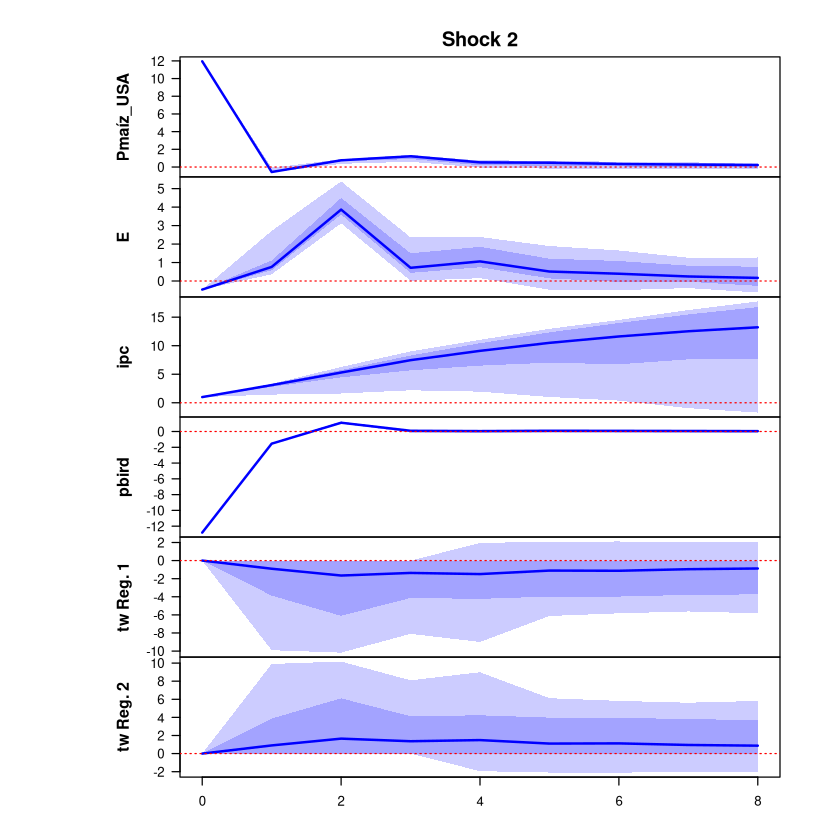

In [14]:
cat("Regimen 1 - ERPT de TC a Inflación (todo en dif log)\n")

girf_erpt <- GIRF(
  fit_struct,
  N = 8,                          # horizonte
  which_shocks = 2,               # shock al Tipo de Cambio (variable 2)
  which_cumulative = 3,           # acumula la respuesta de inflación (variable 3)
  init_regime = 1,
  scale = c(2, 3, 1),          # ← clave: shock a TC que genera +1% (0.01) en inflación instantánea
  scale_type = "instant"          # Recomendado para ERPT
)

plot(girf_erpt, 
     main = "ERPT: Efecto acumulado de inflación ante shock de TC\n(Regimen 2 - Todo en dif log)")

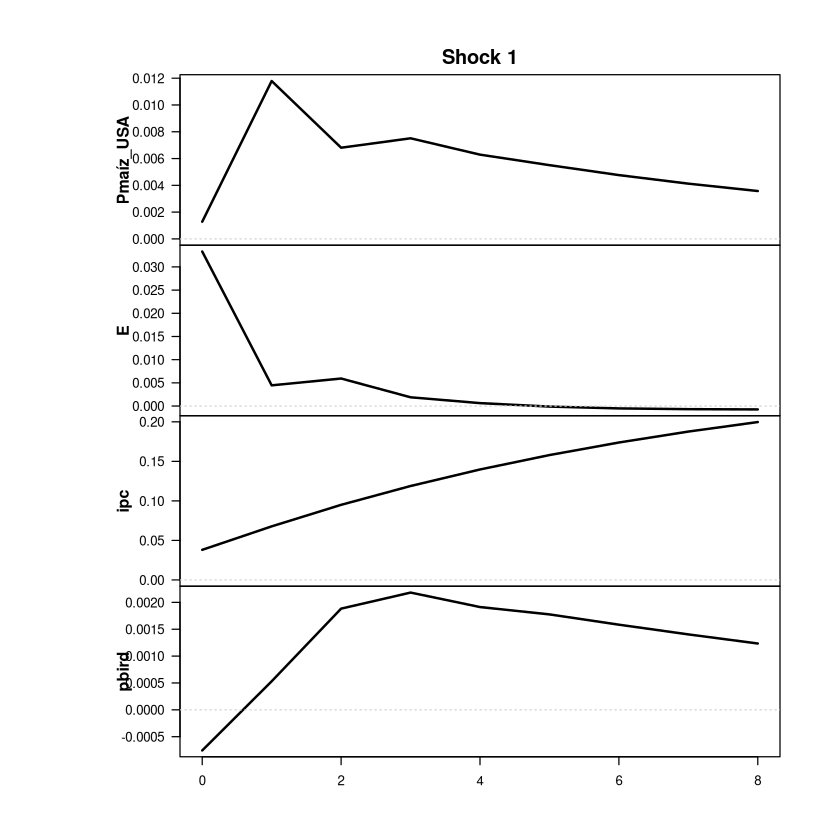

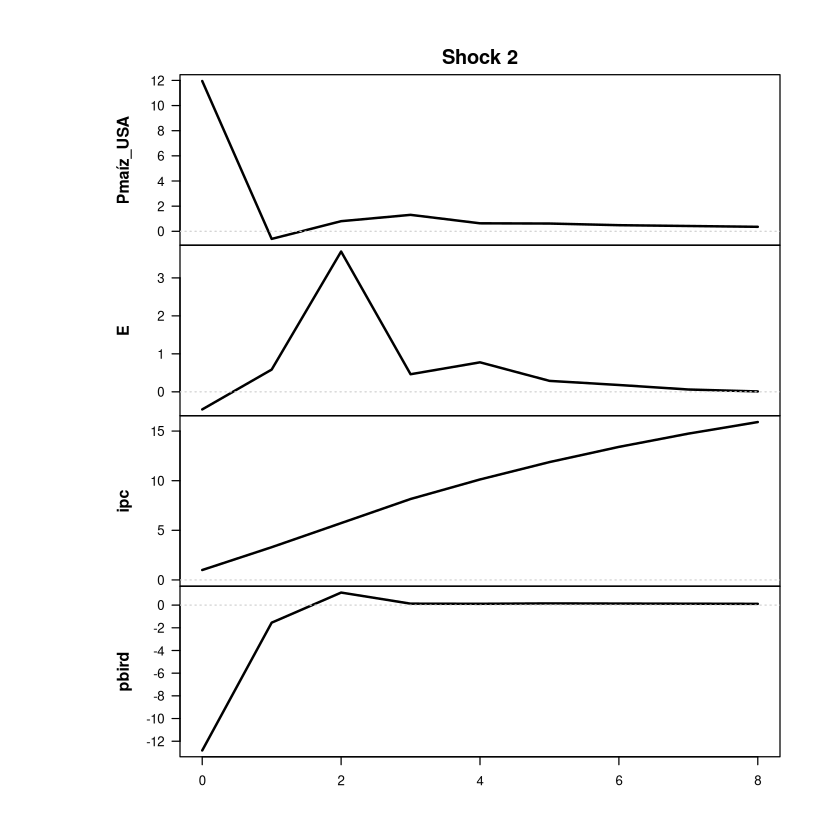

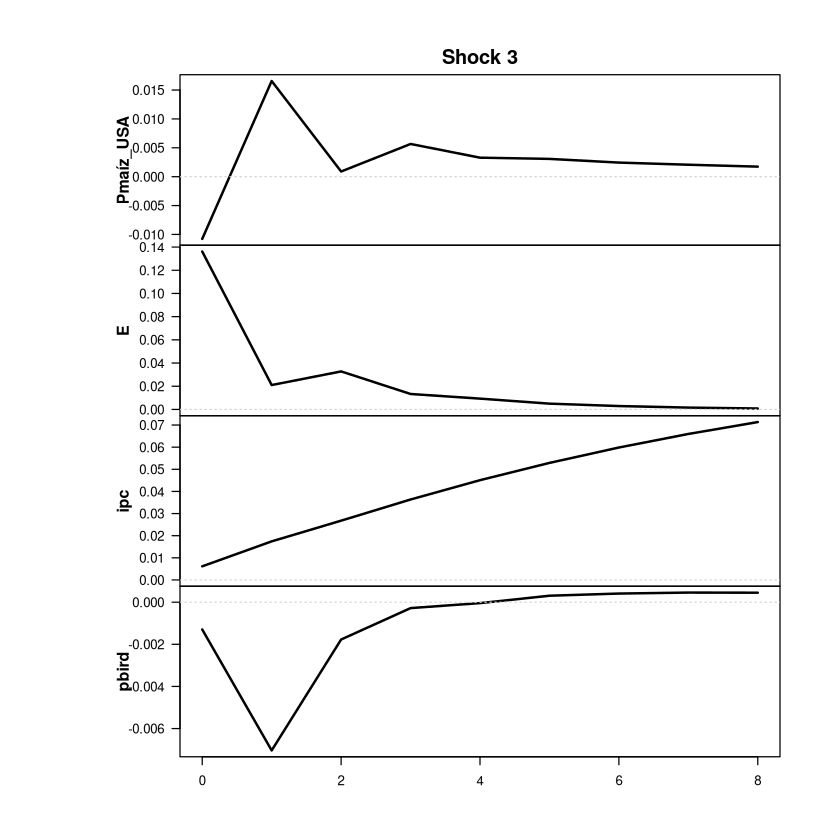

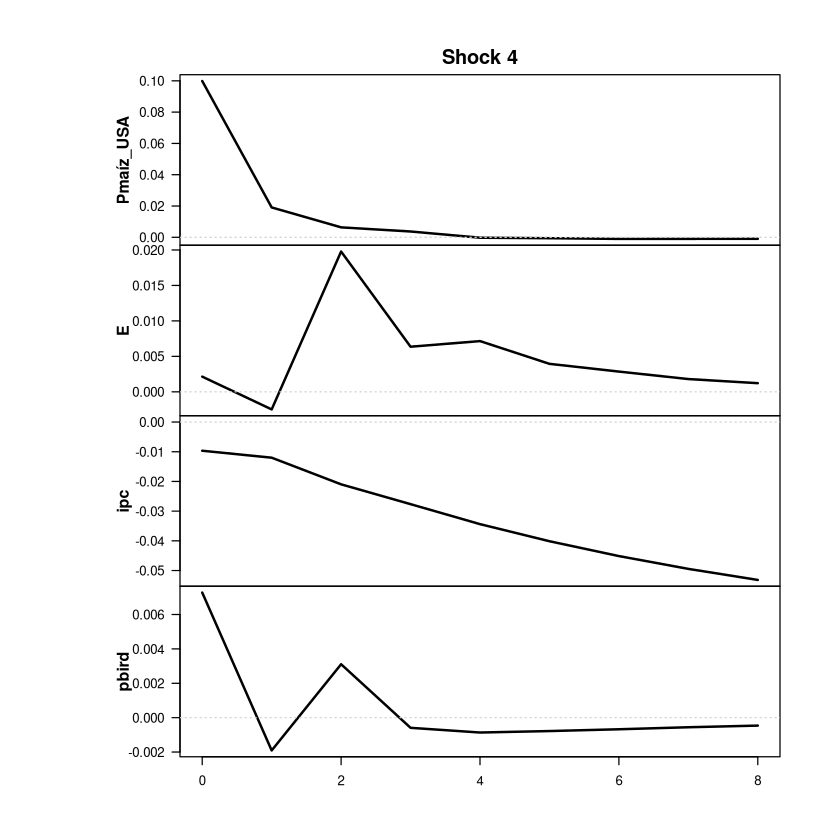

In [15]:
irf_struct <- linear_IRF(
  fit_struct,
  N = 8,                    # horizonte de 8 periodos
  regime = 1,
  which_cumulative = 3,     # acumula las respuestas de la inflación (variable 3)
  scale = c(2, 3, 1),       # ← CLAVE: shock en TC (2) → +1 en inflación (3)
  # scale = matrix(c(2, 3, 1), ncol = 1)   # forma equivalente
  ncores = 2
)

plot(irf_struct)

Regimen 1

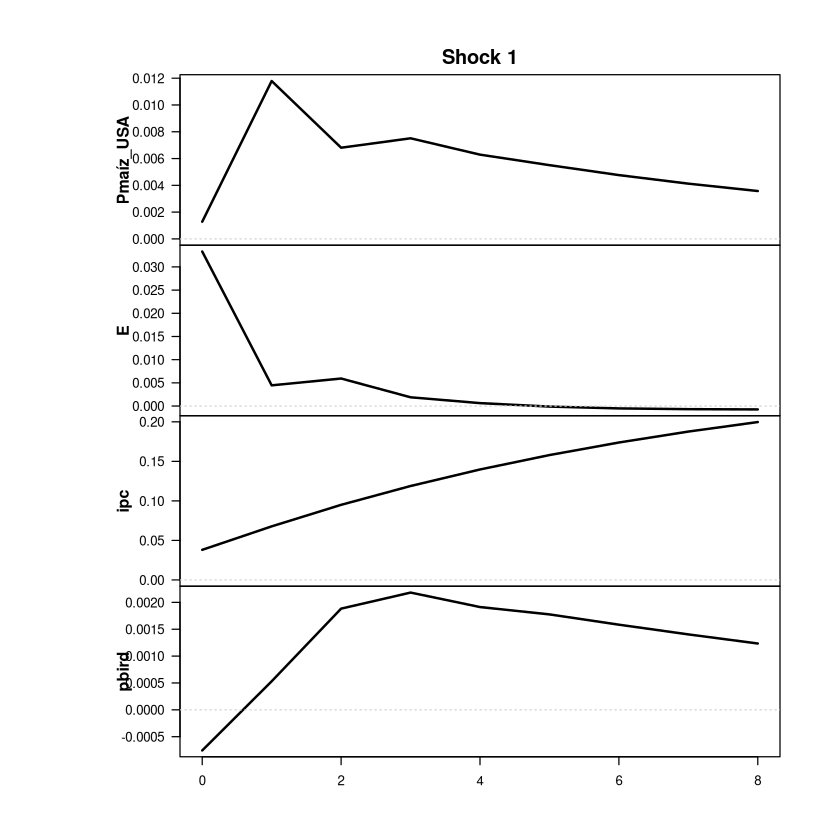

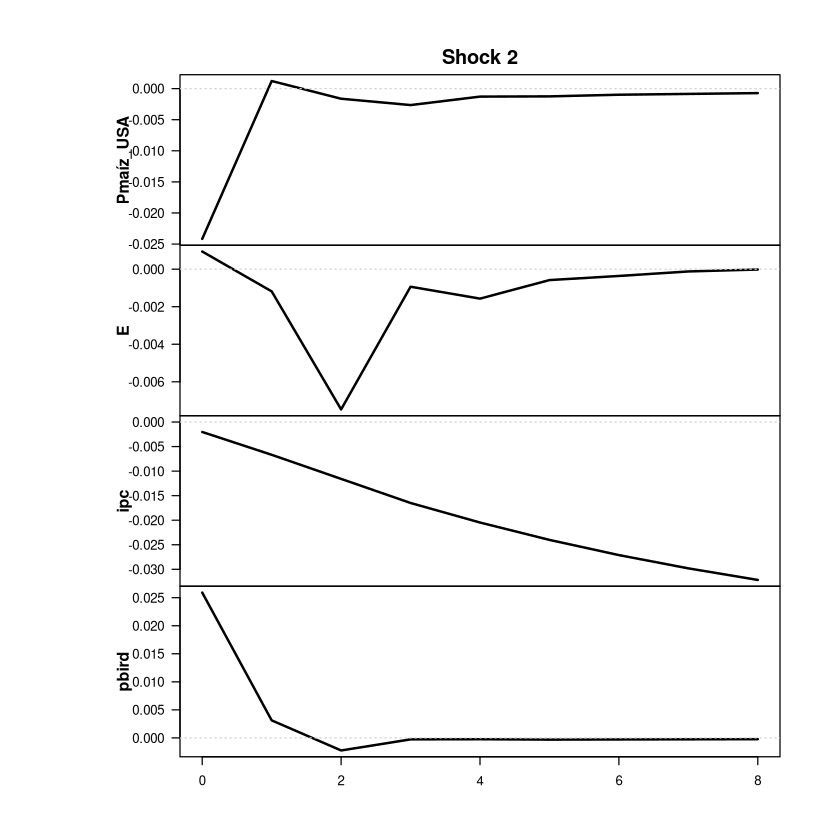

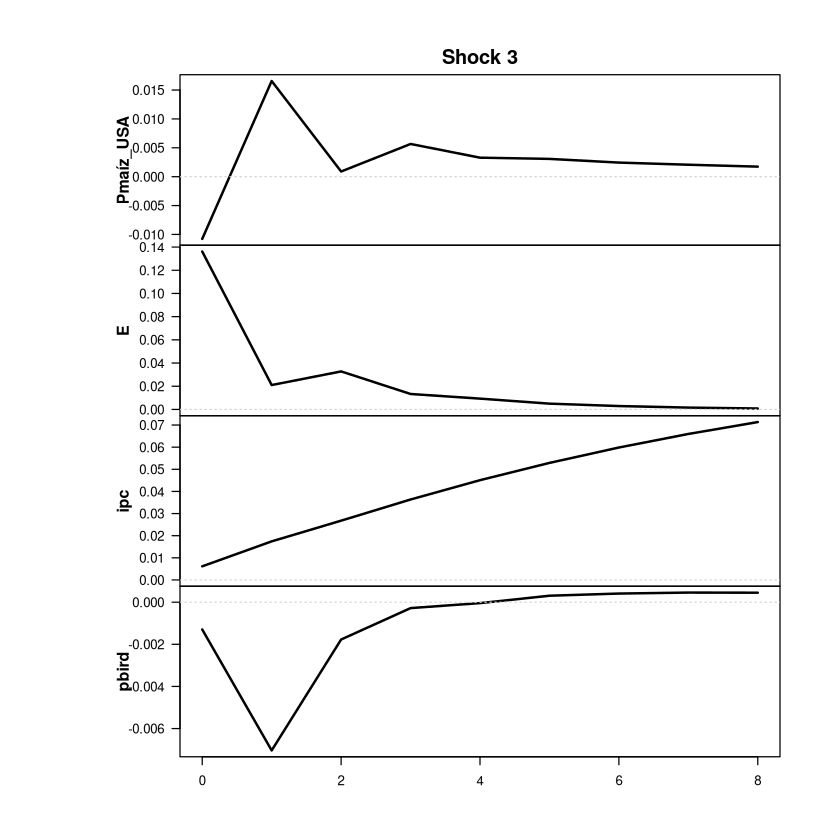

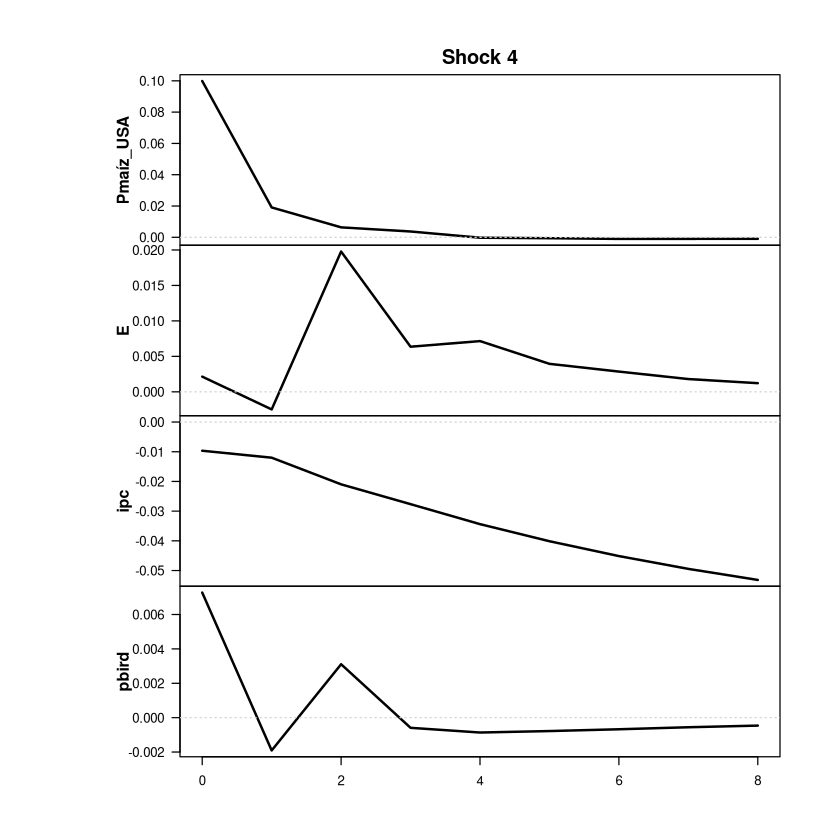

In [16]:
cat("Regimen 1")
irf_struct <- linear_IRF(
  fit_struct,
  N = 8,
  regime = 1,
  which_cumulative = 3,
  #ci = 0.68,
  scale = NULL,
  ncores = 2,
  #robust_method = c("Nelder-Mead", "SANN", "none"),
)
plot(irf_struct)


## Diagnósticos

In [ ]:
alt_stvar(tvar_model, which_largest = 2)
summary(alt_stvar)

In [ ]:

diagnostic_plot(tvar_model)       # residuos
Portmanteau_test(tvar_model)      # autocorrelación
LR_test(tvar_model)               # lineal vs no lineal

# GRÁFICOS

## Configuración global: usando tvar_model
1. ERPT por régimen (IRF del TVAR)
2. ERPT rolling en el tiempo
3. Horizonte 4 y 8 trimestres

In [9]:
data_model <- df_ERPT_Arg[, c("Pmaíz_USA","E","ipc","pbird")]
data_model <- na.omit(data_model)

lag_var   <- lag_var
nthresh   <- nthresh_value
trim_val  <- trim_value
nboot_irf <- nboot_test

shock_var <- "E"
resp_var  <- "ipc"

h_short <- 4
h_long  <- 8


In [10]:
# Renombro test de linearidad para que coincida con el resto del codigo
lr_test <- test_lin


## IRF por regimen ABSOLUTAS

In [11]:
irf_r1 <- vars::irf(
  tvar_model,
  impulse = shock_var,
  response = resp_var,
  regime = "L",
  n.ahead = h_long,
  boot = TRUE,
  runs = nboot_irf,
  ci = 0.68,
  cumulative = FALSE,
  ortho = FALSE
)

In [12]:
irf_r2 <- vars::irf(tvar_model, impulse=shock_var, response=resp_var,
              regime="H", n.ahead=h_long, boot=TRUE, runs=nboot_irf,
              ci = 0.68, cumulative = FALSE, ortho = FALSE)

## ERPT por régimen

In [14]:
get_erpt <- function(irf_obj, h){
  cumsum(irf_obj$irf$E[,"ipc"])[h+1]
}

erpt_reg <- data.frame(
  regime = c("Baja","Alta"),
  ERPT_4 = c(get_erpt(irf_r1,4),
             get_erpt(irf_r2,4)),
  ERPT_8 = c(get_erpt(irf_r1,8),
             get_erpt(irf_r2,8))
)

print(erpt_reg)


  regime   ERPT_4    ERPT_8
1   Baja 0.410726 0.7212973
2   Alta 1.102329 1.3362871


## Gráfico IRF ABSOLUTAS

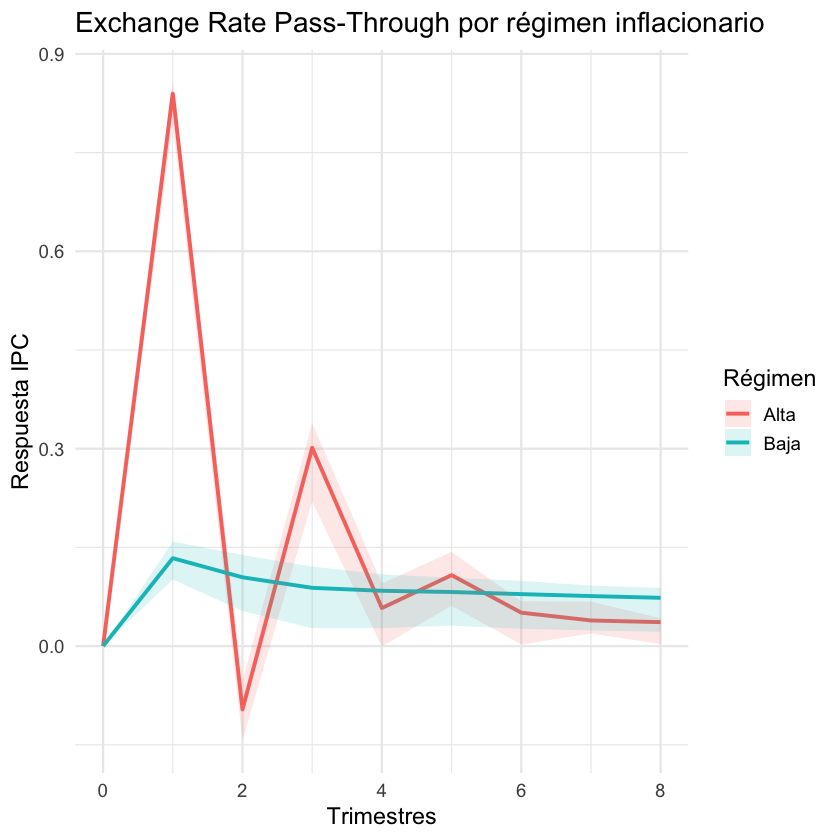

In [16]:
extract_irf <- function(irf_obj, shock, response){

  irf_mat <- irf_obj$irf[[shock]]
  lo_mat  <- irf_obj$Lower[[shock]]
  hi_mat  <- irf_obj$Upper[[shock]]

  data.frame(
    h   = 0:(nrow(irf_mat)-1),
    irf = irf_mat[, response],
    lo  = lo_mat[, response],
    hi  = hi_mat[, response]
  )
}

df1 <- extract_irf(irf_r1, shock = shock_var, response = resp_var); df1$reg="Baja"
df2 <- extract_irf(irf_r2, shock = shock_var, response = resp_var); df2$reg="Alta"

df_all <- rbind(df1,df2)

ggplot(df_all, aes(h, irf, color=reg, fill=reg))+
  geom_line(linewidth=1.1)+
  geom_ribbon(aes(ymin=lo, ymax=hi), alpha=.15, color=NA)+
  theme_minimal(base_size = 14)+
  labs(title="Exchange Rate Pass-Through por régimen inflacionario",
       y="Respuesta IPC",
       x="Trimestres",
       color="Régimen",
       fill="Régimen")


In [17]:
df_all


h,irf,lo,hi,reg
<int>,<dbl>,<dbl>,<dbl>,<chr>
0,0.00000000,0.0000000000,0.00000000,Baja
1,0.13359765,0.1011790712,0.15890905,Baja
2,0.10452907,0.0532776648,0.13845370,Baja
3,0.08854565,0.0271520699,0.12083186,Baja
4,0.08405368,0.0271967500,0.10902813,Baja
5,0.08218882,0.0311038239,0.10403645,Baja
6,0.07898615,0.0261813042,0.09919165,Baja
7,0.07602424,0.0239075762,0.09192900,Baja
8,0.07337209,0.0216584941,0.08854685,Baja


In [18]:
irf_r1$ortho


[1] FALSE

## IRF por régimen ACUMULADAS

Acumulo manualmente las IRF absolutas (el paquete tsDyn no tiene IRF acumuladas)

In [19]:
extract_irf_cum <- function(irf_obj, shock, resp){

  # respuesta puntual
  irf_mat <- irf_obj$irf[[shock]][, resp]
  lo_mat  <- irf_obj$Lower[[shock]][, resp]
  hi_mat  <- irf_obj$Upper[[shock]][, resp]

  data.frame(
    h  = 0:(length(irf_mat)-1),
    irf = cumsum(irf_mat),
    lo  = cumsum(lo_mat),
    hi  = cumsum(hi_mat)
  )
}


In [20]:
df1 <- extract_irf_cum(irf_r1, shock_var, resp_var); df1$reg="Baja"
df2 <- extract_irf_cum(irf_r2, shock_var, resp_var); df2$reg="Alta"

df_all <- rbind(df1, df2)


In [21]:
df_all

h,irf,lo,hi,reg
<int>,<dbl>,<dbl>,<dbl>,<chr>
0,0.0000000,0.0000000,0.0000000,Baja
1,0.1335976,0.1011791,0.1589090,Baja
2,0.2381267,0.1544567,0.2973627,Baja
3,0.3266724,0.1816088,0.4181946,Baja
4,0.4107260,0.2088056,0.5272227,Baja
5,0.4929149,0.2399094,0.6312592,Baja
6,0.5719010,0.2660907,0.7304508,Baja
7,0.6479253,0.2899983,0.8223798,Baja
8,0.7212973,0.3116568,0.9109267,Baja


## Gráficos IRF ACUMULADAS

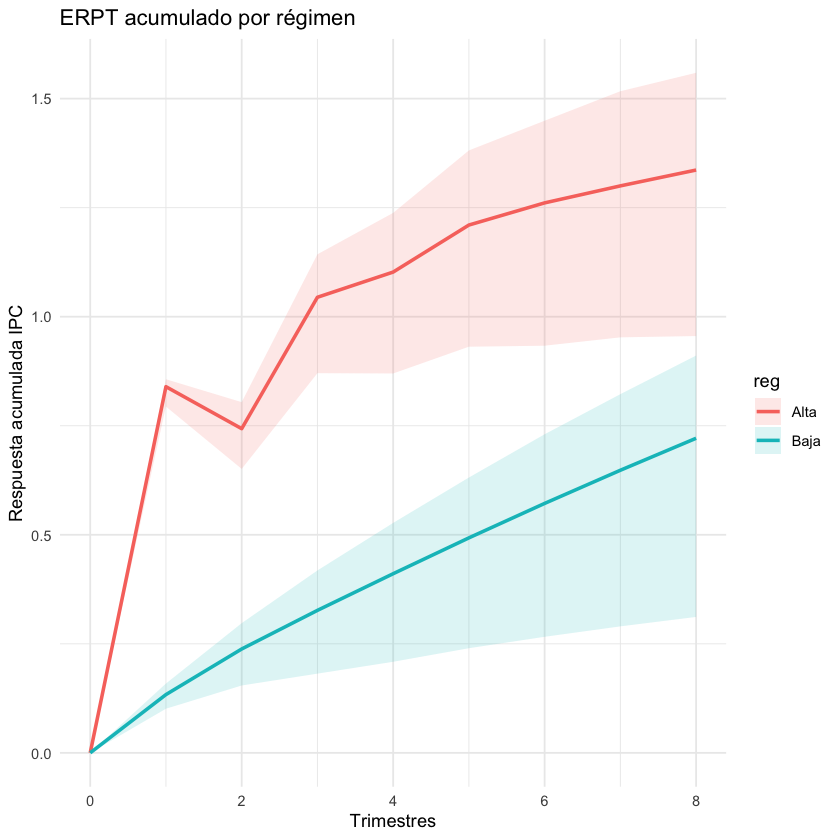

In [22]:
library(ggplot2)

ggplot(df_all, aes(h, irf, color=reg))+
  geom_line(linewidth=1)+
  geom_ribbon(aes(ymin=lo, ymax=hi, fill=reg),
              alpha=.15, color=NA)+
  theme_minimal()+
  labs(title="ERPT acumulado por régimen",
       y="Respuesta acumulada IPC",
       x="Trimestres")
